swra echo-3
→ DiFuMo
→ ROI time series
→ events.tsv split
→ Belief FC
→ Photo FC
→ Belief - Photo

##Load sub1's tomloc2 run-04 echo3

In [10]:
import nibabel as nib
fmri_filepath = '/home/chsinchi/subjects_nii/3814_nii/swra0_sub-ident01_task-tomloc2_run-04_echo-3_bold.nii'


In [11]:
fmri_img = nib.load(fmri_filepath)
print(fmri_img)


<class 'nibabel.nifti1.Nifti1Image'>
data shape (79, 95, 79, 162)
affine:
[[  -2.    0.    0.   78.]
 [   0.    2.    0. -112.]
 [   0.    0.    2.  -70.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4  79  95  79 162   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [-1.  2.  2.  2.  2.  0.  0.  0.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'Warped - conv(8,8,8)'
aux_file        : b''
qform_code      :

##Using DiFuMo64 atlas

In [12]:
from nilearn import datasets
atlas_dataset = datasets.fetch_atlas_difumo(data_dir="/home/chsinchi/Hsin-Chi_Project/3814", dimension=64)
atlas_filepath = atlas_dataset.maps
labels = atlas_dataset.labels

[fetch_atlas_difumo] Dataset found in /home/chsinchi/Hsin-Chi_Project/3814/difumo_atlases

In [13]:
from nilearn.input_data import NiftiMapsMasker
import matplotlib.pyplot as plt

atlas_masker = NiftiMapsMasker(maps_img=atlas_filepath, standardize='zscore_sample', memory='nilearn_cache', memory_level=1)
time_series = atlas_masker.fit_transform(fmri_filepath)
time_series.shape

/tmp/ipykernel_8863/2403797724.py:1: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiMapsMasker


(162, 64)

In [14]:
import pandas as pd

events_path = "/home/chsinchi/subjects_nii/3814_nii/sub-ident01_task-tomloc2_run-04_events.tsv"
events = pd.read_csv(events_path, sep="\t")

events.head()

,onset,duration,trial_type,trial_type_id,question_type,response_time,accuracy,stim_id
0,12,14,Photo,2,1,2.568543,1,photo_story20
1,38,14,Belief,1,2,2.928875,1,belief_story18
2,64,14,Belief,1,1,2.063399,1,belief_story15
3,90,14,Photo,2,2,3.608273,1,photo_story17
4,116,14,Belief,1,2,2.440222,1,belief_story22


In [15]:
events["trial_type"].value_counts()

trial_type
Photo     6
Belief    6
Name: count, dtype: int64

In [16]:
import numpy as np

TR = 2

def extract_condition_ts(time_series, events, condition, tr):
    chunks = []

    condition_events = events[events["trial_type"] == condition]

    for _, row in condition_events.iterrows():
        start = int(row["onset"] / tr)
        end = int((row["onset"] + row["duration"]) / tr)
        chunks.append(time_series[start:end, :])

    return np.vstack(chunks)

In [17]:
photo_ts = extract_condition_ts(time_series, events, "Photo", TR)
belief_ts = extract_condition_ts(time_series, events, "Belief", TR)

print(photo_ts.shape)
print(belief_ts.shape)

(42, 64)
(42, 64)


In [18]:
from nilearn.connectome import ConnectivityMeasure
import numpy as np

correlation_measure = ConnectivityMeasure(kind='correlation')

photo_fc = correlation_measure.fit_transform([photo_ts])[0]
belief_fc = correlation_measure.fit_transform([belief_ts])[0]

np.fill_diagonal(photo_fc, 0)
np.fill_diagonal(belief_fc, 0)

diff_fc = belief_fc - photo_fc

/tmp/ipykernel_8863/3309570408.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  photo_fc = correlation_measure.fit_transform([photo_ts])[0]
/tmp/ipykernel_8863/3309570408.py:7: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the default strategy will be replaced by the new strategy, the 'zscore' option will be removed. and using standardize=True will fall back to 'zscore_sample'.To avoid 

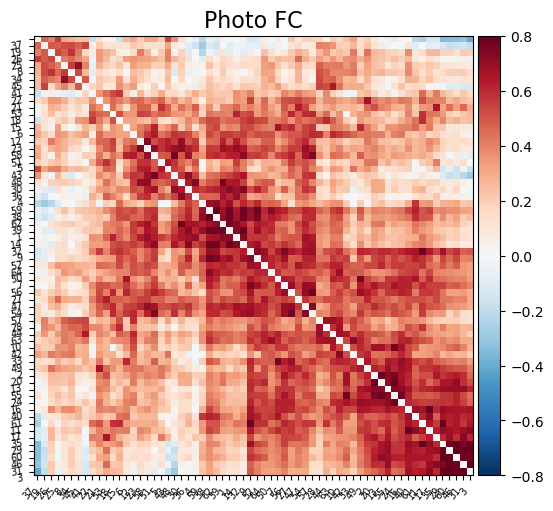

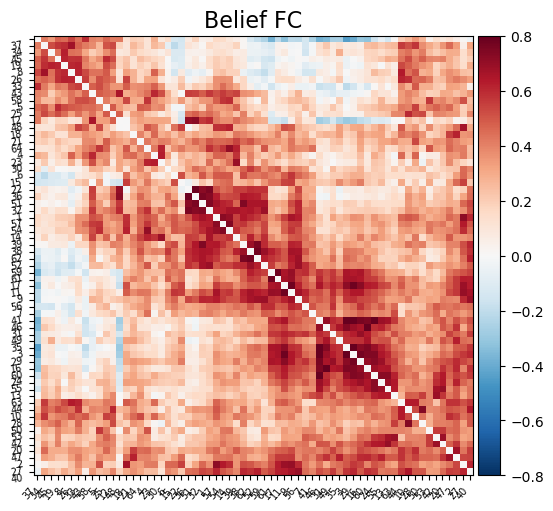

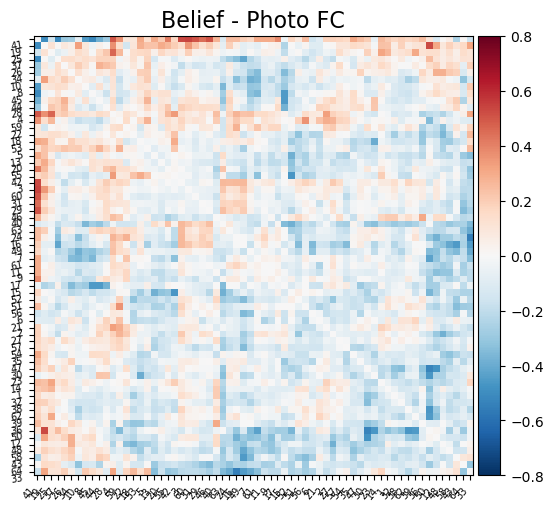

In [22]:
from nilearn import plotting

plotting.plot_matrix(
    photo_fc,
    labels=range(1, time_series.shape[-1] + 1),
    vmax=0.8,
    vmin=-0.8,
    reorder='complete',
    auto_fit=True,
    title="Photo FC"
)

plotting.plot_matrix(
    belief_fc,
    labels=range(1, time_series.shape[-1] + 1),
    vmax=0.8,
    vmin=-0.8,
    reorder='complete',
    auto_fit=True,
    title="Belief FC"
)

plotting.plot_matrix(
    diff_fc,
    labels=range(1, time_series.shape[-1] + 1),
    vmax=0.8,
    vmin=-0.8,
    reorder='complete',
    auto_fit=True,
    title="Belief - Photo FC",
)